In [242]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pandas as pd
from scipy.optimize import minimize, minimize_scalar
from scipy.integrate import quad  # 引入积分模块
import time

try:
    from IPython.display import display
except ImportError:
    display = print

In [243]:
q = 1.0              # total demand

# FW outer-loop parameters
fw_tol = 1e-4
fw_max_iter = 200

# line-search parameters
eps_ls = 1e-4
alpha_max = 1.0

In [244]:
# define cost functions
def t1(x1):
    return x1

def t2(x2):
    return x2

def t3(x3):
    return x3 + 1.0


# define cost vectors
def C(x):
    return np.array(
        [t1(x[0]), t2(x[1]), t3(x[2])]
    )

# define Beckmann function
def Z(x):
    return 0.5*x[0]**2 + 0.5 * x[1]**2 + 0.5 * x[2] **2 +x[2]

# define AON assignment
def AON(cost):
    y = np.zeros_like(cost)
    shortest_path_index = np.argmin(cost)
    y[shortest_path_index] = q
    return y


In [245]:
'''
x1, x2, x3 = 0, 0, 0
x_free = np.array([x1, x2, x3])
print(x_free)
free_cost = C(x_free)
x = AON(free_cost)
print(free_cost)
print(x)
'''

'\nx1, x2, x3 = 0, 0, 0\nx_free = np.array([x1, x2, x3])\nprint(x_free)\nfree_cost = C(x_free)\nx = AON(free_cost)\nprint(free_cost)\nprint(x)\n'

In [246]:
x1, x2, x3 = 0.2, 0.6, 0.2
x = np.array([x1, x2, x3])
cost = C(x)
y = AON(cost)
d = y - x
print(cost)
print(y)
print(d)

[0.2 0.6 1.2]
[1. 0. 0.]
[ 0.8 -0.6 -0.2]


In [247]:
def x_alpha(x, d, alpha):
    return x + alpha * d

In [248]:
print(x_alpha(x, d, 0.0))
print(x_alpha(x, d, 0.5))
print(x_alpha(x, d, 1.0))

[0.2 0.6 0.2]
[0.6 0.3 0.1]
[1. 0. 0.]


In [249]:
def phi(x, d, alpha):
    return Z(x_alpha(x, d, alpha))

In [250]:
print(phi(x, d, 0.0))
print(phi(x, d, 0.5))
print(phi(x, d, 1.0))

0.42000000000000004
0.33000000000000007
0.5


In [251]:
def phi_prime(x, d, alpha):
    return np.dot(C(x_alpha(x, d, alpha)), d)

In [252]:
print(phi_prime(x, d, 0.0))
print(phi_prime(x, d, 0.5))
print(phi_prime(x, d, 1.0))


-0.43999999999999995
0.08000000000000007
0.6000000000000001


In [253]:
'''
def line_search_bisection(x, d, eps_ls, line_max_iter=100): # 这里没有规定具体的数，也可以在这里规定
    left = 0.0
    right = 1.0

    n_ls = 0
    derivative_evals = 0 # 加一个计数器,计求导的次数

    # tol = 1e-10 数值精度容忍度，表示小于这个区间就认为其为0
    # max_iter = 100 规定二分法二分的次数
    g_left = phi_prime(x, d, left)
    derivative_evals += 1

    if g_left >= 0:
      return left, n_ls, derivative_evals


    g_right = phi_prime(x, d, right)
    derivative_evals += 1

    if g_right <= 0:
      return right, n_ls, derivative_evals

    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:
      mid = (left + right) / 2.0
      g_mid = phi_prime(x, d, mid)
      derivative_evals += 1

      if g_mid < 0:
        left = mid
      else:
        right = mid
      n_ls += 1

    # 注意！这里phi_prime被算了两次（这部分暂时不要）


    #for _ in range(line_max_iter):
    #  mid = (left + right) / 2.0
    #  if abs(phi_prime(x, d, mid)) < eps_ls:
    #    return mid

    #  if phi_prime(x, d, mid) < 0:
    #    left = mid
    #  else:
    #    right = mid

    alpha = (left + right) / 2.0
    return alpha, n_ls, derivative_evals
'''

'\ndef line_search_bisection(x, d, eps_ls, line_max_iter=100): # 这里没有规定具体的数，也可以在这里规定\n    left = 0.0\n    right = 1.0 \n\n    n_ls = 0\n    derivative_evals = 0 # 加一个计数器,计求导的次数\n\n    # tol = 1e-10 数值精度容忍度，表示小于这个区间就认为其为0\n    # max_iter = 100 规定二分法二分的次数\n    g_left = phi_prime(x, d, left)\n    derivative_evals += 1\n\n    if g_left >= 0:\n      return left, n_ls, derivative_evals\n    \n    \n    g_right = phi_prime(x, d, right)\n    derivative_evals += 1\n\n    if g_right <= 0:\n      return right, n_ls, derivative_evals\n\n    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:\n      mid = (left + right) / 2.0\n      g_mid = phi_prime(x, d, mid)\n      derivative_evals += 1\n\n      if g_mid < 0:\n        left = mid\n      else:\n        right = mid\n      n_ls += 1\n\n    # 注意！这里phi_prime被算了两次（这部分暂时不要）\n\n\n    #for _ in range(line_max_iter):\n    #  mid = (left + right) / 2.0\n    #  if abs(phi_prime(x, d, mid)) < eps_ls:\n    #    return mid\n      \n    #  if phi_prime

In [254]:
# vibe version
def line_search_bisection(x, d, eps_ls, line_max_iter=100):
    line_start_time = time.perf_counter()

    left = 0.0
    right = 1.0

    n_ls = 0
    derivative_evals = 0

    # evaluate phi'(left)
    g_left = phi_prime(x, d, left)
    derivative_evals += 1

    if g_left >= 0:
        alpha = left
        line_runtime = time.perf_counter() - line_start_time
        return alpha, n_ls, derivative_evals, line_runtime

    # evaluate phi'(right)
    g_right = phi_prime(x, d, right)
    derivative_evals += 1

    if g_right <= 0:
        alpha = right
        line_runtime = time.perf_counter() - line_start_time
        return alpha, n_ls, derivative_evals, line_runtime

    # bisection interval reduction
    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:
        mid = (left + right) / 2.0

        # evaluate phi'(mid) only once
        g_mid = phi_prime(x, d, mid)
        derivative_evals += 1

        if g_mid < 0:
            left = mid
        else:
            right = mid

        n_ls += 1

    alpha = (left + right) / 2.0

    line_runtime = time.perf_counter() - line_start_time

    return alpha, n_ls, derivative_evals, line_runtime

In [255]:
def fw_gap(x, y):
    return np.dot(C(x), x - y)

In [256]:
# 基础款函数FW算法
'''
def frank_wolfe(x, fw_tol, fw_max_iter, eps_ls):
    history = []

    for n in range(fw_max_iter):
      y = AON(C(x))
      gap = fw_gap(x, y)

      # print("Iteration", n)
      # print("x^n =", x)
      # print("t(x^n) =", C(x))
      # print("y^n =", y)
      # print("gap =", gap)

      if gap < fw_tol:
        print("converged at iteration", n)
        break

      d = y - x
      alpha, n_ls, derivative_evals = line_search_bisection(x, d, eps_ls=eps_ls)

      history.append([n, alpha, n_ls, derivative_evals, gap])

      x = x_alpha(x, d, alpha)

      # print("d^n =", d)
      # print("alpha^n =", alpha)
      # print("x^{n+1} =", x)
      # print("-" * 40)

    history = pd.DataFrame(history, columns=["fw_iter", "alpha", "n_ls", "derivative_evals", "gap"])

    return x, history

solution, history = frank_wolfe(x, fw_tol, fw_max_iter, eps_ls)

print("Final solution:", solution)
print("Final cost:", C(solution))
print("Final objective:", Z(solution))


display(history)


plt.figure(figsize=(8, 4))
plt.plot(history["fw_iter"], history["n_ls"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("N_ls")
plt.title("Bisection line-search iterations per FW iteration")
plt.grid(True)
plt.show()
'''

'\ndef frank_wolfe(x, fw_tol, fw_max_iter, eps_ls):\n    history = []\n\n    for n in range(fw_max_iter):\n      y = AON(C(x))\n      gap = fw_gap(x, y)\n\n      # print("Iteration", n)\n      # print("x^n =", x)\n      # print("t(x^n) =", C(x))\n      # print("y^n =", y)\n      # print("gap =", gap)\n\n      if gap < fw_tol:\n        print("converged at iteration", n)\n        break\n\n      d = y - x\n      alpha, n_ls, derivative_evals = line_search_bisection(x, d, eps_ls=eps_ls)\n\n      history.append([n, alpha, n_ls, derivative_evals, gap])\n\n      x = x_alpha(x, d, alpha)\n\n      # print("d^n =", d)\n      # print("alpha^n =", alpha)\n      # print("x^{n+1} =", x)\n      # print("-" * 40)\n\n    history = pd.DataFrame(history, columns=["fw_iter", "alpha", "n_ls", "derivative_evals", "gap"])\n\n    return x, history\n\nsolution, history = frank_wolfe(x, fw_tol, fw_max_iter, eps_ls)\n\nprint("Final solution:", solution)\nprint("Final cost:", C(solution))\nprint("Final objective:

In [257]:

# vibe coding for recording
def frank_wolfe(x, fw_tol, fw_max_iter, eps_ls):
    history = []

    total_n_ls = 0
    total_derivative_evals = 0

    total_start_time = time.perf_counter()

    for n in range(fw_max_iter):
        iter_start_time = time.perf_counter()

        cost = C(x)
        y = AON(cost)
        gap = fw_gap(x, y)
        obj = Z(x)

        if gap < fw_tol:
            print("converged at iteration", n)
            break

        d = y - x

        alpha, n_ls, derivative_evals, line_runtime = line_search_bisection(
            x, d, eps_ls=eps_ls
        )

        total_n_ls += n_ls
        total_derivative_evals += derivative_evals

        x_next = x_alpha(x, d, alpha)

        iter_runtime = time.perf_counter() - iter_start_time
        cumulative_runtime = time.perf_counter() - total_start_time

        history.append([
            n,
            x[0], x[1], x[2],
            cost[0], cost[1], cost[2],
            y[0], y[1], y[2],
            d[0], d[1], d[2],
            obj,
            gap,
            alpha,
            n_ls,
            derivative_evals,
            total_n_ls,
            total_derivative_evals,
            line_runtime,
            iter_runtime,
            cumulative_runtime,
            x_next[0], x_next[1], x_next[2]
        ])

        x = x_next

    history = pd.DataFrame(
        history,
        columns=[
            "fw_iter",
            "x1", "x2", "x3",
            "cost1", "cost2", "cost3",
            "y1", "y2", "y3",
            "d1", "d2", "d3",
            "Z",
            "gap",
            "alpha",
            "n_ls",
            "derivative_evals",
            "total_n_ls",
            "total_derivative_evals",
            "line_runtime",
            "iter_runtime",
            "cumulative_runtime",
            "x1_next", "x2_next", "x3_next"
        ]
    )

    return x, history

# 重新定义一下初始 x 流量 (如果你之前改过)
x_init = np.array([0.2, 0.6, 0.2])

# 调用新函数，覆盖旧的 solution 和 history
solution, history = frank_wolfe(x_init, fw_tol, fw_max_iter, eps_ls)

print("新的 history 成功生成！")
display(history.head())


新的 history 成功生成！


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,derivative_evals,total_n_ls,total_derivative_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
0,0,0.200000,0.600000,0.200000,0.200000,0.600000,1.200000,1.0,0.0,0.0,...,13,15,13,15,0.000192,0.000823,0.000826,0.538428,0.346179,0.115393
1,1,0.538428,0.346179,0.115393,0.538428,0.346179,1.115393,0.0,1.0,0.0,...,13,15,26,30,0.000134,0.000207,0.001039,0.396755,0.518214,0.085031
2,2,0.396755,0.518214,0.085031,0.396755,0.518214,1.085031,1.0,0.0,0.0,...,13,15,39,45,0.000132,0.000189,0.001233,0.511300,0.419815,0.068885
3,3,0.511300,0.419815,0.068885,0.511300,0.419815,1.068885,0.0,1.0,0.0,...,13,15,52,60,0.000125,0.000157,0.001394,0.433687,0.507884,0.058429
4,4,0.433687,0.507884,0.058429,0.433687,0.507884,1.058429,1.0,0.0,0.0,...,13,15,65,75,0.000131,0.000160,0.001558,0.505893,0.443128,0.050979


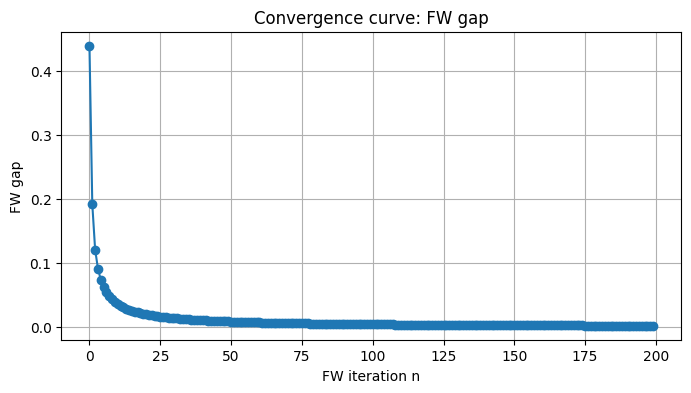

In [258]:
plt.figure(figsize=(8, 4))
plt.plot(history["fw_iter"], history["gap"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("FW gap")
plt.title("Convergence curve: FW gap")
plt.grid(True)
plt.show()

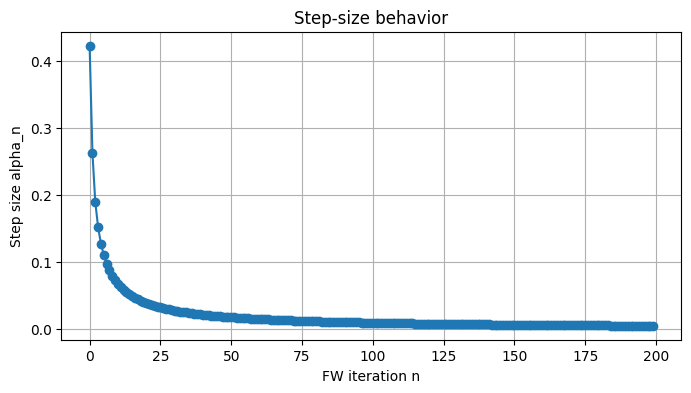

In [260]:
plt.figure(figsize=(8, 4))
plt.plot(history["fw_iter"], history["alpha"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Step size alpha_n")
plt.title("Step-size behavior")
plt.grid(True)
plt.show()

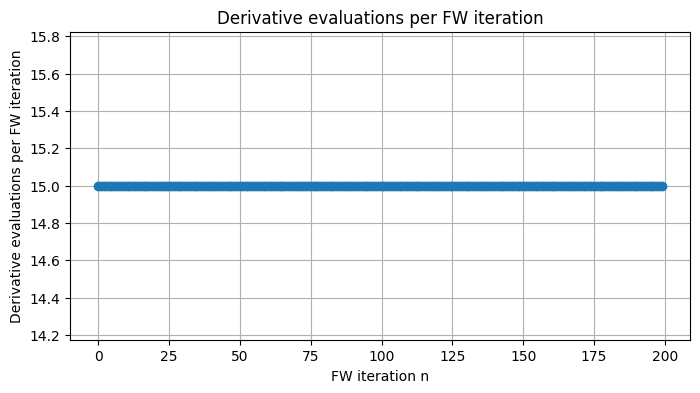

In [261]:
plt.figure(figsize=(8, 4))
plt.plot(history["fw_iter"], history["derivative_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Derivative evaluations per FW iteration")
plt.title("Derivative evaluations per FW iteration")
plt.grid(True)
plt.show()

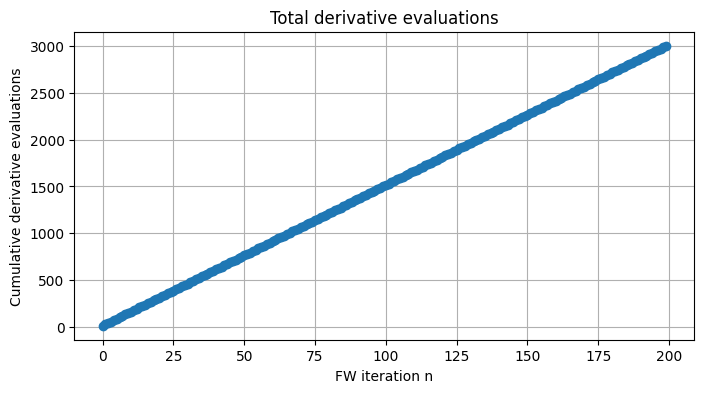

In [262]:
plt.figure(figsize=(8, 4))
plt.plot(history["fw_iter"], history["total_derivative_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Cumulative derivative evaluations")
plt.title("Total derivative evaluations")
plt.grid(True)
plt.show()

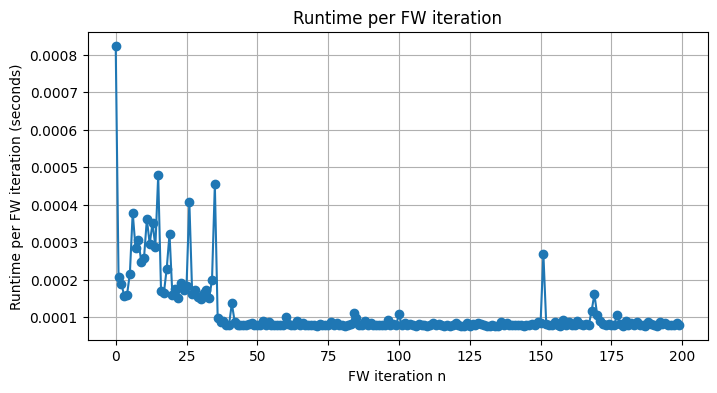

In [263]:
plt.figure(figsize=(8, 4))
plt.plot(history["fw_iter"], history["iter_runtime"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Runtime per FW iteration (seconds)")
plt.title("Runtime per FW iteration")
plt.grid(True)
plt.show()

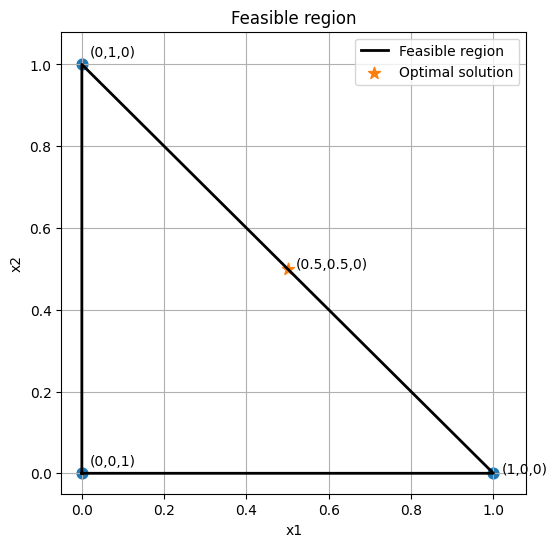

In [264]:
plt.figure(figsize=(6, 6))

# feasible region boundary: x1 >= 0, x2 >= 0, x1 + x2 <= 1
triangle_x = [0, 1, 0, 0]
triangle_y = [0, 0, 1, 0]

plt.plot(triangle_x, triangle_y, "k-", linewidth=2, label="Feasible region")

# mark three vertices
plt.scatter([1, 0, 0], [0, 1, 0], s=60)
plt.text(1.02, 0.00, "(1,0,0)", fontsize=10)
plt.text(0.02, 1.02, "(0,1,0)", fontsize=10)
plt.text(0.02, 0.02, "(0,0,1)", fontsize=10)

# mark optimal solution
plt.scatter([0.5], [0.5], s=80, marker="*", label="Optimal solution")
plt.text(0.52, 0.50, "(0.5,0.5,0)", fontsize=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Feasible region")
plt.xlim(-0.05, 1.08)
plt.ylim(-0.05, 1.08)
plt.grid(True)
plt.legend()
plt.show()

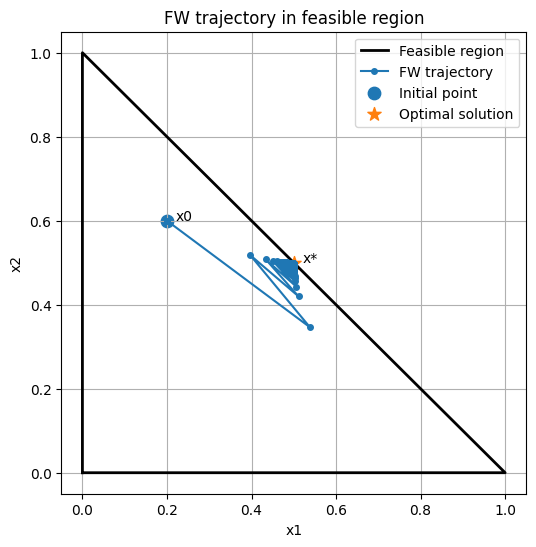

In [265]:
plt.figure(figsize=(6, 6))

# feasible region
plt.plot([0, 1, 0, 0], [0, 0, 1, 0], "k-", linewidth=2, label="Feasible region")

# FW trajectory
plt.plot(
    history["x1"],
    history["x2"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="FW trajectory"
)

# initial point
plt.scatter([history.loc[0, "x1"]], [history.loc[0, "x2"]], s=80, label="Initial point")
plt.text(history.loc[0, "x1"] + 0.02, history.loc[0, "x2"], "x0", fontsize=10)

# optimal point
plt.scatter([0.5], [0.5], s=100, marker="*", label="Optimal solution")
plt.text(0.52, 0.50, "x*", fontsize=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("FW trajectory in feasible region")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

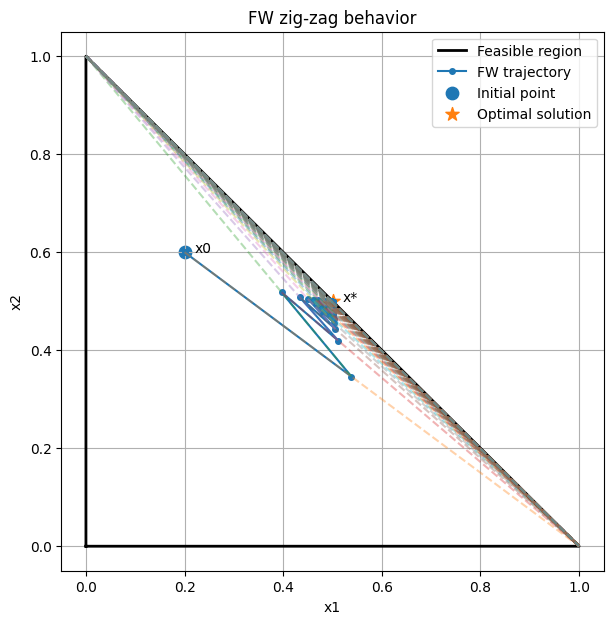

In [266]:
plt.figure(figsize=(7, 7))

# feasible region boundary
plt.plot([0, 1, 0, 0], [0, 0, 1, 0], "k-", linewidth=2, label="Feasible region")

# FW trajectory
plt.plot(
    history["x1"],
    history["x2"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="FW trajectory"
)

# draw zig-zag search directions x^n -> y^n
for i in range(len(history)):
    x1_now = history.loc[i, "x1"]
    x2_now = history.loc[i, "x2"]
    y1_now = history.loc[i, "y1"]
    y2_now = history.loc[i, "y2"]

    plt.plot(
        [x1_now, y1_now],
        [x2_now, y2_now],
        linestyle="--",
        alpha=0.35
    )

# mark initial point
plt.scatter([history.loc[0, "x1"]], [history.loc[0, "x2"]], s=80, label="Initial point")
plt.text(history.loc[0, "x1"] + 0.02, history.loc[0, "x2"], "x0", fontsize=10)

# mark optimal solution
plt.scatter([0.5], [0.5], s=100, marker="*", label="Optimal solution")
plt.text(0.52, 0.50, "x*", fontsize=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("FW zig-zag behavior")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()